# Protein-to-genome tools: validation + speed comparison

This notebook **runs the real tools from the terminal** (it shells out to the
benchmark scripts) and compares how they map protein-domain amino-acid
coordinates onto the genome. Nothing here is pre-computed — every number and
plot below is produced by the cells as they run.

It rolls the old `validation` and `software_comparison` notebooks into one
live run: **are the coordinates correct** (per stratum), and **how fast / how
much memory** does each tool use.

| Tool | What it is |
|---|---|
| **prot2exon** | our C++ binary with a pre-built index |
| **ensembldb::proteinToGenome** | the Bioconductor canonical (R, SQLite-backed) |
| **GenomicFeatures::proteinToGenome** | a second Bioconductor implementation (R, in-memory GRanges) |
| **VisProDom `CreDat()`** | an R viewer's batch mapper (pure R, no index) — characterized separately |
| **geneplot** | Python *visualization* only — not a mapper (shown for context) |

**Prerequisites** (this is a benchmark notebook — it needs the comparison
environment): the prot2exon binary under `build/`, R with `ensembldb`,
`GenomicFeatures`, and `EnsDb.Hsapiens.v86`, and the stratified query set
`queries_v86.bed`. See `benchmarks/README.md`.

## The scripts, in plain language

Everything below is driven by a few small scripts in `benchmarks/`. What each
one does, without jargon:

- **`proteintogenome_bench.R <tool> ...`** — runs *one* R mapper (`ensembldb`
  or `genomicfeatures`) on a batch of queries. It writes two files: the genomic
  intervals it found, and a tiny "timing" file (setup time, mapping time, and
  the peak memory the process used). One run per tool, so each tool's memory is
  measured on its own.
- **`prot2exon map ...`** — the prot2exon command. Loads the index once, maps
  all the queries, and prints how long the load and the mapping took.
- **`compare_intervals.py a=... b=...`** — the referee. It reduces every query
  to a *set of (chrom, start, end, strand) pieces* and checks whether two tools
  produced **exactly the same pieces**. We also import its loaders here to score
  agreement *per stratum*.
- **`visprodom_bench.R <repo>`** — times VisProDom's `CreDat()` mapper at
  100 / 1,000 / 10,000 domains and the full set.

Splitting the work into scripts means the **same scripts** produce the numbers
whether you run them here or from a plain shell — the notebook just drives them
and draws the charts.

In [1]:
# --- Setup: locate repo, data, binary, EnsDb; build a balanced stratified subset ---
import os, subprocess, re, sys
from pathlib import Path

start = Path.cwd()
REPO = next((p for p in [start, *start.parents]
             if (p / "benchmarks" / "proteintogenome_bench.R").exists()), start)
os.chdir(REPO)
print("repo root :", REPO)

BIN = REPO / "build" / "prot2exon"
DATA = Path(os.environ.get("PROT2EXON_BENCH_DATA",
                           Path.home() / "Desktop" / "protein2genomic_data"))
QUERIES = DATA / "queries_v86.bed"
INDEX = DATA / "human_v86.idx"
ENSDB = subprocess.run(
    ["Rscript", "-e",
     'cat(system.file("extdata/EnsDb.Hsapiens.v86.sqlite", package="EnsDb.Hsapiens.v86"))'],
    capture_output=True, text=True).stdout.strip()
for label, p in [("binary", BIN), ("queries", QUERIES), ("index", INDEX), ("EnsDb", Path(ENSDB))]:
    print(f"{label:8s}: {p}  {'OK' if Path(p).exists() else 'MISSING'}")

# queries_v86.bed is sorted by stratum, so take up to 100 per stratum for a
# balanced set across all 9 conditions (single/multi-exon, both strands,
# codon-split, incomplete CDS, selenoproteins, single/many-exon genes).
def stratum(qid): return re.sub(r"^Q\d+_", "", qid)
per_stratum, lines = {}, []
for ln in QUERIES.read_text().splitlines():
    s = stratum(ln.split("\t")[3])
    if per_stratum.get(s, 0) < 100:
        per_stratum[s] = per_stratum.get(s, 0) + 1
        lines.append(ln)

WORK = REPO / "benchmarks" / "_ptg_run"
WORK.mkdir(exist_ok=True)
QSET = WORK / "qset.bed"
QSET.write_text("\n".join(lines) + "\n")
print(f"\nstratified subset: {len(lines)} queries across {len(per_stratum)} strata")
for s, n in sorted(per_stratum.items()):
    print(f"  {s:22s} {n}")

repo root : /home/goguxor/Desktop/protein2genomic


binary  : /home/goguxor/Desktop/protein2genomic/build/prot2exon  OK
queries : /home/goguxor/Desktop/protein2genomic_data/queries_v86.bed  OK
index   : /home/goguxor/Desktop/protein2genomic_data/human_v86.idx  OK
EnsDb   : /home/goguxor/R/library/EnsDb.Hsapiens.v86/extdata/EnsDb.Hsapiens.v86.sqlite  OK

stratified subset: 900 queries across 9 strata
  cds_incomplete         100
  codon_split_boundary   100
  many_exon_gene         100
  minus_strand_gene      100
  multi_exon_domain      100
  plus_strand_gene       100
  selenoprotein          100
  single_exon_domain     100
  single_exon_gene       100


## 1. prot2exon

Load the index once and map the queries. prot2exon prints its own timers and a
peak-RSS line we parse out.

In [2]:
t = subprocess.run(
    [str(BIN), "map", "--index", str(INDEX), "--bed", str(QSET),
     "--out-dir", str(WORK / "p2e"), "--output", "coding"],
    capture_output=True, text=True)
print(t.stderr.strip()[-500:])

def grab(pat, txt, cast=float):
    m = re.search(pat, txt); return cast(m.group(1)) if m else None
p2e_load_ms = grab(r"Index loading completed in (\d+)ms", t.stderr)
p2e_map_ms  = grab(r"Domain mapping completed in (\d+)ms", t.stderr)
p2e_rss_mb  = grab(r"BENCH_PEAK_RSS_MB (\d+)", t.stderr)
print(f"\nprot2exon: load={p2e_load_ms} ms, map={p2e_map_ms} ms, peak RSS={p2e_rss_mb} MB")

uxor/Desktop/protein2genomic/benchmarks/_ptg_run/qset.bed
Domain loading completed in 0ms
Mapped 900/900 queries (0 unmapped) in 23ms
Domain mapping completed in 23ms
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_mapping_summary.tsv
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_cds_segments.tsv
Wrote /home/goguxor/Desktop/protein2genomic/benchmarks/_ptg_run/p2e/domain_cds_segments.bed
Memory: current=672MB peak=672MB
BENCH_PEAK_RSS_MB 672

prot2exon: load=1841.0 ms, map=23.0 ms, peak RSS=672.0 MB


## 2. ensembldb::proteinToGenome (R, SQLite-backed)

The Bioconductor canonical — queries the EnsDb SQLite per call. The slow one
(~5 queries/second), so this cell takes a few minutes.

In [3]:
r = subprocess.run(
    ["Rscript", "benchmarks/proteintogenome_bench.R", "ensembldb", ENSDB,
     str(QSET), str(WORK / "ens_intervals.tsv"), str(WORK / "ens_timing.tsv")],
    capture_output=True, text=True)
print([l for l in r.stdout.splitlines() if l.startswith("RESULT")][0])

RESULT tool=ensembldb setup_s=0.000 map_s=235.624 total_s=235.624 peak_rss_mb=1163


## 3. GenomicFeatures::proteinToGenome (R, in-memory GRanges)

The second Bioconductor implementation. Builds a CDS-by-transcript object once
(`cdsBy`, the "setup" time) and then maps in memory — faster than ensembldb,
but still an R loop.

In [4]:
r = subprocess.run(
    ["Rscript", "benchmarks/proteintogenome_bench.R", "genomicfeatures", ENSDB,
     str(QSET), str(WORK / "gf_intervals.tsv"), str(WORK / "gf_timing.tsv")],
    capture_output=True, text=True)
print([l for l in r.stdout.splitlines() if l.startswith("RESULT")][0])

RESULT tool=genomicfeatures setup_s=11.338 map_s=58.192 total_s=69.530 peak_rss_mb=1364


## 4. Validation — do the coordinates match, per stratum?

We import the referee's loaders and score, **for each stratum**, whether
prot2exon returns the exact same genomic segments as each R tool. (The overall
referee line is printed too.)

In [5]:
r = subprocess.run(
    [sys.executable, "benchmarks/compare_intervals.py",
     f"ensembldb={WORK/'ens_intervals.tsv'}",
     f"genomicfeatures={WORK/'gf_intervals.tsv'}",
     f"prot2exon={WORK/'p2e'/'domain_cds_segments.tsv'}"],
    capture_output=True, text=True)
print(r.stdout)

# Per-stratum agreement using the same loaders.
sys.path.insert(0, str(REPO / "benchmarks"))
import importlib, compare_intervals as ci; importlib.reload(ci)
ens = ci.load_rgranges(WORK / "ens_intervals.tsv")
gf  = ci.load_rgranges(WORK / "gf_intervals.tsv")
p2e = ci.load_prot2exon(WORK / "p2e" / "domain_cds_segments.tsv")

import pandas as pd
strata = sorted({stratum(q) for q in p2e})
def per_stratum_match(a, b):
    out = {}
    for s in strata:
        common = [q for q in a if stratum(q) == s and q in b]
        out[s] = 100.0 * sum(a[q] == b[q] for q in common) / len(common) if common else float("nan")
    return out
qual = pd.DataFrame({
    "ensembldb vs prot2exon": per_stratum_match(p2e, ens),
    "GenomicFeatures vs prot2exon": per_stratum_match(p2e, gf),
})
qual.round(2)

loaded: ensembldb=900 queries, genomicfeatures=900 queries, prot2exon=900 queries

ensembldb        vs genomicfeatures : 900/900 exact-segment match (100.00%)
ensembldb        vs prot2exon       : 900/900 exact-segment match (100.00%)
genomicfeatures  vs prot2exon       : 900/900 exact-segment match (100.00%)



,ensembldb vs prot2exon,GenomicFeatures vs prot2exon
cds_incomplete,100.0,100.0
codon_split_boundary,100.0,100.0
many_exon_gene,100.0,100.0
minus_strand_gene,100.0,100.0
multi_exon_domain,100.0,100.0
plus_strand_gene,100.0,100.0
selenoprotein,100.0,100.0
single_exon_domain,100.0,100.0
single_exon_gene,100.0,100.0


## 5. Speed + memory table

In [6]:
rows = []
for tool, tf in [("ensembldb", WORK / "ens_timing.tsv"), ("genomicfeatures", WORK / "gf_timing.tsv")]:
    d = pd.read_csv(tf, sep="\t").iloc[0].to_dict()
    nq = d["n_queries"]
    rows.append({"tool": tool, "setup_s": d["setup_s"], "map_s": d["map_s"],
                 "total_s": d["total_s"], "peak_rss_mb": d["peak_rss_mb"],
                 "map_q_per_s": nq / d["map_s"]})
n = len(lines)
rows.insert(0, {"tool": "prot2exon", "setup_s": p2e_load_ms / 1000, "map_s": p2e_map_ms / 1000,
                "total_s": (p2e_load_ms + p2e_map_ms) / 1000, "peak_rss_mb": p2e_rss_mb,
                "map_q_per_s": n / (p2e_map_ms / 1000)})
df = pd.DataFrame(rows).set_index("tool")
df.round(2)

,setup_s,map_s,total_s,peak_rss_mb,map_q_per_s
tool,,,,,
prot2exon,1.84,0.02,1.86,672.0,39130.43
ensembldb,0.00,235.62,235.62,1163.0,3.82
genomicfeatures,11.34,58.19,69.53,1364.0,15.47


## 6. The comparison plots

Four panels: **validation** (per-stratum agreement), **throughput**,
**peak memory**, and **end-to-end time**.

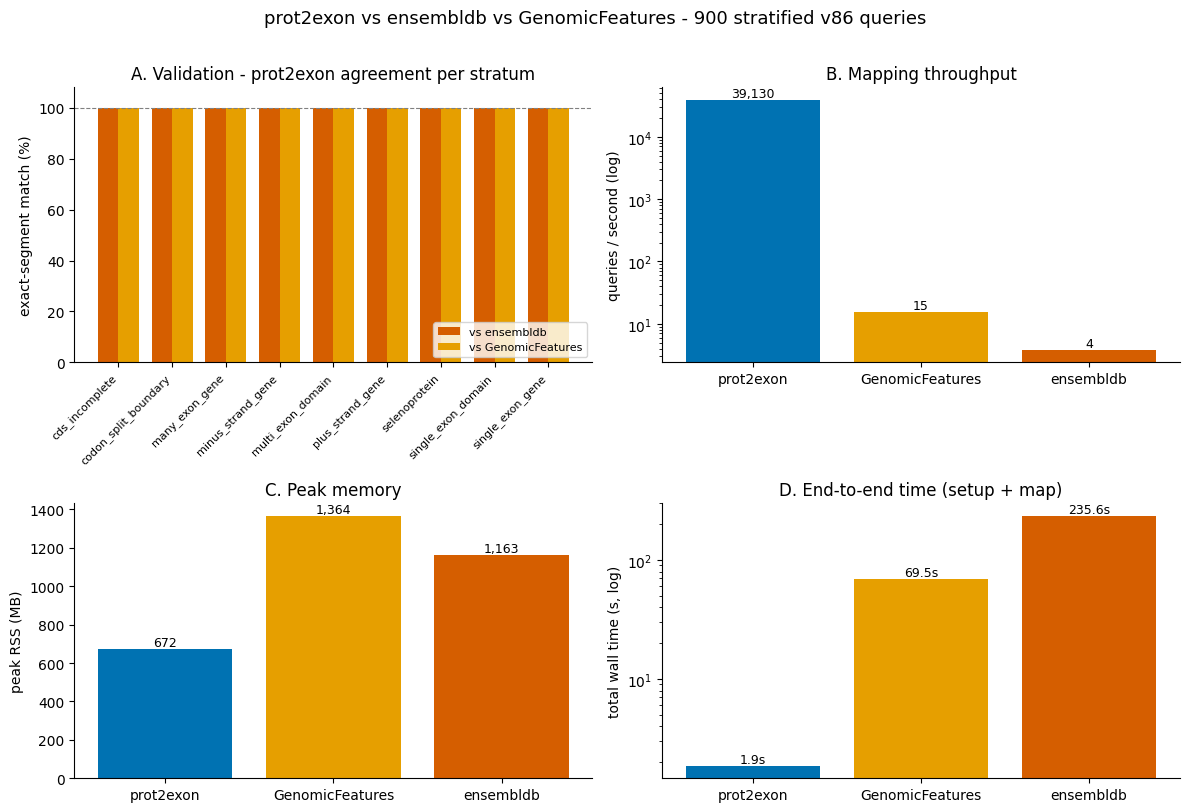

In [7]:
import matplotlib.pyplot as plt
import numpy as np
WONG = {"prot2exon": "#0072B2", "genomicfeatures": "#E69F00", "ensembldb": "#D55E00"}
order = ["prot2exon", "genomicfeatures", "ensembldb"]
d = df.loc[order]
cols = [WONG[t] for t in order]
labels = ["prot2exon", "GenomicFeatures", "ensembldb"]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# (A) Validation: per-stratum exact-match %
axA = ax[0, 0]
x = np.arange(len(qual.index)); w = 0.38
axA.bar(x - w/2, qual["ensembldb vs prot2exon"], w, label="vs ensembldb", color="#D55E00")
axA.bar(x + w/2, qual["GenomicFeatures vs prot2exon"], w, label="vs GenomicFeatures", color="#E69F00")
axA.set_xticks(x); axA.set_xticklabels(qual.index, rotation=45, ha="right", fontsize=8)
axA.set_ylim(0, 108); axA.axhline(100, ls="--", lw=0.8, color="grey")
axA.set_ylabel("exact-segment match (%)")
axA.set_title("A. Validation - prot2exon agreement per stratum")
axA.legend(fontsize=8, loc="lower right")

# (B) Mapping throughput (log)
axB = ax[0, 1]
axB.bar(labels, d["map_q_per_s"], color=cols)
axB.set_yscale("log"); axB.set_ylabel("queries / second (log)")
axB.set_title("B. Mapping throughput")
for i, v in enumerate(d["map_q_per_s"]):
    axB.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# (C) Peak RAM
axC = ax[1, 0]
axC.bar(labels, d["peak_rss_mb"], color=cols)
axC.set_ylabel("peak RSS (MB)"); axC.set_title("C. Peak memory")
for i, v in enumerate(d["peak_rss_mb"]):
    axC.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=9)

# (D) End-to-end time (log)
axD = ax[1, 1]
axD.bar(labels, d["total_s"], color=cols)
axD.set_yscale("log"); axD.set_ylabel("total wall time (s, log)")
axD.set_title("D. End-to-end time (setup + map)")
for i, v in enumerate(d["total_s"]):
    axD.text(i, v, f"{v:,.1f}s", ha="center", va="bottom", fontsize=9)

for a in ax.flat:
    a.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"prot2exon vs ensembldb vs GenomicFeatures - {n} stratified v86 queries",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

All three tools return **identical genomic coordinates** (panel A is 100%
everywhere), but the speed and memory differ by orders of magnitude (panels
B-D). GenomicFeatures' in-memory GRanges path beats ensembldb's SQLite, yet both
are still R loops - thousands of times slower per query than the indexed C++
path, at more memory.

## 7. VisProDom - a batch mapper with no index

VisProDom's `CreDat()` genuinely maps domains to the genome (pure R), but with
**no prebuilt index**: every call rebuilds the whole genome's CDS layout, so it
is **O(genome), not O(queries)**. We run it on its bundled maize example and
plot the wall time against the number of domains - it stays flat.

VPD N=100    wall_s=9.00 mapped_rows=61483 peak_rss_mb=760
VPD N=1000   wall_s=6.66 mapped_rows=65358 peak_rss_mb=847
VPD N=10000  wall_s=8.49 mapped_rows=101154 peak_rss_mb=864
VPD FULL     wall_s=15.93 mapped_rows=262392 peak_rss_mb=928


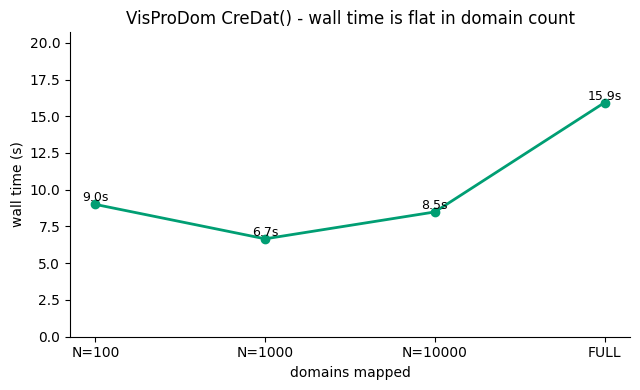

In [8]:
vpd = Path("/tmp/VisProDom")
if not vpd.exists():
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/whweve/VisProDom", str(vpd)],
                   capture_output=True, text=True)
r = subprocess.run(["Rscript", "benchmarks/visprodom_bench.R", str(vpd)],
                   capture_output=True, text=True)
vpd_lines = [l for l in r.stdout.splitlines() if l.startswith("VPD")]
print("\n".join(vpd_lines))

pts = []
for l in vpd_lines:
    lbl = re.search(r"VPD\s+(\S+)", l).group(1)
    w = float(re.search(r"wall_s=([\d.]+)", l).group(1))
    pts.append((lbl, w))
fig, axv = plt.subplots(figsize=(6.5, 4))
xs = [p[0] for p in pts]; ys = [p[1] for p in pts]
axv.plot(xs, ys, "o-", color="#009E73", lw=2)
axv.set_ylim(0, max(ys) * 1.3); axv.set_ylabel("wall time (s)")
axv.set_xlabel("domains mapped"); axv.set_title("VisProDom CreDat() - wall time is flat in domain count")
for xi, yi in zip(xs, ys):
    axv.text(xi, yi, f"{yi:.1f}s", ha="center", va="bottom", fontsize=9)
axv.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

The line is flat: mapping 100 domains costs about the same as 10,000,
because the time goes into rebuilding the maize gene models, not the queries.
A persistent index (what prot2exon has) is exactly what removes this.

## 8. geneplot - not a mapper

For completeness: **geneplot** (Python) is a *plotting* library (`gffutils` +
BioPython `GenomeDiagram`). It draws domains whose coordinates are **already**
mapped (it reads a GFF3 + an InterProScan file), so it performs no
protein->genome mapping and isn't in the comparison above - it's a peer of
prot2exon's plotting, not its mapper.

## Takeaways

- **Same answers:** prot2exon = ensembldb = GenomicFeatures, 100% per stratum.
- **Very different cost:** prot2exon maps in milliseconds; GenomicFeatures beats
  ensembldb but both are thousands of times slower per query, at more memory.
- **Indexing matters:** VisProDom shows the price of no index - the whole-genome
  cost on every call.